<a href="https://colab.research.google.com/github/afaq47dev/Data-Science-assignment-3/blob/main/global_terrorism_EDA%20(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Terrorism Analysis (UNGTA Dataset)

## Project Type: Exploratory Data Analysis (EDA)
## Contribution: Individual
## Creator : Afaq Ahamd

## Project Summary
The United Nations Global Terrorism Analysis (UNGTA) dataset is a comprehensive, open-source repository of terrorist incidents from 1970 to 2017, containing over 180,000 recorded attacks worldwide. This notebook performs end-to-end EDA — from data loading and cleaning through feature engineering and visualisation — to extract actionable insights about the evolving landscape of global terrorism.

## Approach:

**Step 1** – Load & understand the dataset (shape, dtypes, duplicates, missing values)
**Step 2** – Exploratory Data Analysis
**Step 3** – Feature Engineering & Data Pre-processing
**Step 4** – Insights & Conclusions

DATASET LOADING AND IMPORTING LIBRARIES

In [ ]:
import pandas as pd
import numpy as np

#Visualisation
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings

# Stats
from scipy import stats
from scipy.stats import chi2_contingency

# Load the dataset
df = pd.read_csv('/content/Global Terrorism Data.csv', encoding='latin1' , low_memory=False)
print(f"Dataset Loaded with SHape - : {df.shape} ")



Dataset Loaded with SHape - : (5096, 135) 


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0.0,0.0,0.0,0.0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0.0,1.0,1.0,1.0,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN


DATASET FIRST LOOK

In [ ]:
# Display the first 5 rows of the DataFrame
display(df.head())

DATASET INFO

In [ ]:
print(df.info(verbose=True, show_counts=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5096 entries, 0 to 5095
Data columns (total 135 columns):
 #    Column              Non-Null Count  Dtype  
---   ------              --------------  -----  
 0    eventid             5096 non-null   int64  
 1    iyear               5096 non-null   int64  
 2    imonth              5096 non-null   int64  
 3    iday                5096 non-null   int64  
 4    approxdate          16 non-null     object 
 5    extended            5096 non-null   int64  
 6    resolution          158 non-null    object 
 7    country             5096 non-null   int64  
 8    country_txt         5096 non-null   object 
 9    region              5096 non-null   int64  
 10   region_txt          5096 non-null   object 
 11   provstate           5083 non-null   object 
 12   city                5096 non-null   object 
 13   latitude            5006 non-null   float64
 14   longitude           5006 non-null   float64
 15   specificity         5096 non-null   

In [ ]:
display(df.describe())

,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,181685.000000,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2.002705e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,1.451452,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,1.325957e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,0.995430,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,1.000000,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,1.000000,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


DUPLICATE CHECK

In [ ]:
# ── Check for duplicate rows ─────────────────────────────────────────────
dup_count = df.duplicated().sum()
print(f"Total duplicate rows: {dup_count}")

Total duplicate rows: 0


DATASET CLEANING

In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('[^a-zA-Z0-9_]', '', regex=True)
print('Cleaned column names:')
print(df.columns)

Cleaned column names:
Index(['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended',
       'resolution', 'country', 'country_txt', 'region',
       ...
       'addnotes', 'scite1', 'scite2', 'scite3', 'dbsource', 'int_log',
       'int_ideo', 'int_misc', 'int_any', 'related'],
      dtype='object', length=135)


MISSING/NULL VALUES

In [ ]:
# Calculate the percentage of missing values for each column
missing_values_percentage = df.isnull().sum() * 100 / len(df)

# Display columns with missing values, sorted by percentage
missing_values_df = pd.DataFrame({'column_name': missing_values_percentage.index, 'missing_percentage': missing_values_percentage.values})
missing_values_df = missing_values_df[missing_values_df['missing_percentage'] > 0].sort_values(by='missing_percentage', ascending=False)

display(missing_values_df.reset_index(drop=True).head(20)) # Display top 20 columns with most missing values

,column_name,missing_percentage
0,gsubname3,99.988992
1,weapsubtype4_txt,99.961473
2,weapsubtype4,99.961473
3,weaptype4_txt,99.959822
4,weaptype4,99.959822
5,claimmode3,99.926799
6,claimmode3_txt,99.926799
7,gsubname2,99.911938
8,claim3,99.824978
9,guncertain3,99.823877


The output above shows a significant number of columns with missing values, some with over 99% missing. This initial analysis helps us determine which columns might be unsuitable for direct use due to excessive missing data and which ones require imputation or other handling strategies.

2.Understanding the variables

In [ ]:
# ── Column names ─────────────────────────────────────────────────────────
print("All columns in the dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:3}. {col}")

All columns in the dataset:
    1. eventid
    2. iyear
    3. imonth
    4. iday
    5. approxdate
    6. extended
    7. resolution
    8. country
    9. country_txt
   10. region
   11. region_txt
   12. provstate
   13. city
   14. latitude
   15. longitude
   16. specificity
   17. vicinity
   18. location
   19. summary
   20. crit1
   21. crit2
   22. crit3
   23. doubtterr
   24. alternative
   25. alternative_txt
   26. multiple
   27. success
   28. suicide
   29. attacktype1
   30. attacktype1_txt
   31. attacktype2
   32. attacktype2_txt
   33. attacktype3
   34. attacktype3_txt
   35. targtype1
   36. targtype1_txt
   37. targsubtype1
   38. targsubtype1_txt
   39. corp1
   40. target1
   41. natlty1
   42. natlty1_txt
   43. targtype2
   44. targtype2_txt
   45. targsubtype2
   46. targsubtype2_txt
   47. corp2
   48. target2
   49. natlty2
   50. natlty2_txt
   51. targtype3
   52. targtype3_txt
   53. targsubtype3
   54. targsubtype3_txt
   55. corp3
   56. target3
   5

In [ ]:
# ── Statistical description (numeric columns) ────────────────────────────
df.describe().T.style.background_gradient(cmap='Oranges').set_properties(
    **{'border': '2px black', 'color': 'black'})

,count,mean,std,min,25%,50%,75%,max
eventid,5096.000000,197387215090.869507,233557060.745673,197000000001.000000,197205130001.750000,197409160005.500000,197605150001.250000,197707300001.000000
iyear,5096.000000,1973.809066,2.337862,1970.000000,1972.000000,1974.000000,1976.000000,1977.000000
imonth,5096.000000,6.158359,3.293888,0.000000,3.000000,6.000000,9.000000,12.000000
iday,5096.000000,15.303375,9.140459,0.000000,7.000000,15.000000,23.000000,31.000000
extended,5096.000000,0.030808,0.172815,0.000000,0.000000,0.000000,0.000000,1.000000
country,5096.000000,271.445840,204.761573,4.000000,98.000000,217.000000,362.000000,605.000000
region,5096.000000,5.754513,3.378390,1.000000,1.000000,8.000000,8.000000,12.000000
latitude,5006.000000,36.559454,22.836022,-43.532054,35.800916,41.400635,52.501530,59.332788
longitude,5006.000000,-26.458558,51.475161,-157.818968,-73.931351,-5.956210,7.519113,172.636225
specificity,5096.000000,1.098705,0.594603,1.000000,1.000000,1.000000,1.000000,5.000000


## Variable Description

| Column Name | Data Type | Description |
|:------------|:----------|:------------|
| `eventid`   | `int64`   | Unique identifier for each event. |
| `iyear`     | `int64`   | Year of the incident. |
| `imonth`    | `int64`   | Month of the incident. |
| `iday`      | `int64`   | Day of the incident. |
| `approxdate`| `object`  | Approximate date of the incident if exact date is unknown. |
| `extended`  | `int64`   | Denotes if the duration of the incident exceeded 24 hours (1=Yes, 0=No). |
| `country_txt`| `object`  | Name of the country where the incident occurred. |
| `region_txt`| `object`  | Name of the region where the incident occurred. |
| `provstate` | `object`  | Province or state where the incident occurred. |
| `city`      | `object`  | City where the incident occurred. |
| `latitude`  | `float64` | Latitude of the incident location. |
| `longitude` | `float64` | Longitude of the incident location. |
| `specificity`| `int64`   | Indicates the specificity of the attack location (1=specific, 2=somewhat specific, 3=not specific). |
| `vicinity`  | `int64`   | Indicates if the incident occurred in the immediate vicinity of the listed location (1=Yes, 0=No). |
| `summary`   | `object`  | Brief summary of the incident. |
| `crit1`     | `int64`   | Criterion 1: Political, economic, religious, or social goal. |
| `crit2`     | `int64`   | Criterion 2: Intention to coerce, intimidate, or publicize. |
| `crit3`     | `int64`   | Criterion 3: Outside international humanitarian law. |
| `doubtterr` | `int64`   | Indicates if there is doubt regarding whether the incident is terrorism (1=Yes, 0=No, -9=Unknown). |
| `multiple`  | `int64`   | Indicates if the incident was part of a multiple attack (1=Yes, 0=No). |
| `success`   | `int64`   | Denotes if the attack was successful (1=Yes, 0=No). |
| `suicide`   | `int64`   | Denotes if the attack was a suicide attack (1=Yes, 0=No). |
| `attacktype1_txt`| `object`| Type of attack (e.g., Bombing/Explosion, Assassination). |
| `targtype1_txt`| `object`| Type of target (e.g., Business, Private Citizens & Property). |
| `gname`     | `object`  | Name of the perpetrator group. |
| `weaptype1_txt`| `object`| Type of weapon used (e.g., Explosives, Firearms). |
| `nkill`     | `float64` | Number of fatalities. |
| `nwound`    | `float64` | Number of injured. |
| `property`  | `int64`   | Indicates if there was property damage (1=Yes, 0=No). |
| `dbsource`  | `object`  | Source of the data. |
| `int_log`   | `float64` | International incident: Logistical (1=Yes, 0=No, -9=Unknown). |
| `int_ideo`  | `float64` | International incident: Ideological (1=Yes, 0=No, -9=Unknown). |
| `int_misc`  | `float64` | International incident: Miscellaneous (1=Yes, 0=No, -9=Unknown). |
| `int_any`   | `float64` | International incident: Any (1=Yes, 0=No, -9=Unknown). |
| `related`   | `object`  | Related incidents. |
| ...         | ...       | ... (This table can be extended based on relevant columns) |

In [ ]:
# ── Checking unique values for key categorical columns ─────────────────────
key_cat_cols = ['region_txt', 'attacktype1_txt', 'targtype1_txt',
                'weaptype1_txt', 'success', 'suicide']

for col in key_cat_cols:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].value_counts().head(10).to_string())
    print("-" * 60)


region_txt (11 unique values):
region_txt
Western Europe                 2578
North America                  1327
South America                   472
Middle East & North Africa      428
Central America & Caribbean      99
Sub-Saharan Africa               60
Southeast Asia                   58
East Asia                        26
Eastern Europe                   22
South Asia                       14
------------------------------------------------------------

attacktype1_txt (10 unique values):
attacktype1_txt
Bombing/Explosion                      2308
Assassination                          1141
Armed Assault                           642
Facility/Infrastructure Attack          615
Hostage Taking (Kidnapping)             256
Hijacking                                48
Hostage Taking (Barricade Incident)      44
Unknown                                  28
Unarmed Assault                          13
Hostage Taking (Kid                       1
-------------------------------------------

3 . DATA CLEANING

Before processing the dataset, we carefully select the columns to retain using these principles:

* **Relevance** – The column should contribute directly to the analysis purpose (who, what, where, when, and how).
* **Completeness** – Columns with over 60% missing values are excluded since heavy imputation can weaken accuracy.
* **Redundancy** – When two or more columns represent the same information (such as `country` and `country_txt`), only the clearer descriptive column is retained.
* **Practical Value** – Columns that support meaningful insights for stakeholders, like casualties, responsible groups, and attack categories, are kept.


In [ ]:
# Drop columns with more than 70% missing values
# The threshold of 70% is chosen as a common practice to remove columns that are largely empty and unlikely to provide much useful information.
columns_to_drop = missing_values_df[missing_values_df['missing_percentage'] > 70]['column_name'].tolist()
df = df.drop(columns=columns_to_drop)

print(f"Dropped {len(columns_to_drop)} columns with more than 70% missing values.")
print(f"Remaining columns: {df.shape[1]}")

Dropped 71 columns with more than 70% missing values.
Remaining columns: 64


Now that we've removed columns with a high percentage of missing values, we need to address the remaining missing values in other columns. For this, we'll implement specific imputation strategies based on the nature of each column. Numerical columns might be filled with the mean or median, while categorical columns can be filled with their mode or a placeholder like 'Unknown'.

In [ ]:
# Impute missing numerical values with the median
# The median is often preferred over the mean for imputation when the data might be skewed by outliers.
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Impute missing categorical values with 'Unknown'
# For categorical columns, creating an 'Unknown' category is a robust way to handle missing data without altering existing distributions.
for col in df.select_dtypes(include=['object']).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna('Unknown')

print("Missing values handled for remaining columns.")
# Verify that there are no more missing values
print("Total missing values after handling:", df.isnull().sum().sum())

Missing values handled for remaining columns.
Total missing values after handling: 0


In [ ]:
#Handle numeric casualties columns ─────────────────────────────────
# nkill / nwound: fill NaN with 0 (no kill/wound reported ≈ 0)
# Rationale: NaN in these columns generally means no data was recorded,
# not that casualties are unknown; most verified attacks have 0 casualties reported.

df['nkill']  = df['nkill'].fillna(0).clip(lower=0)
df['nwound'] = df['nwound'].fillna(0).clip(lower=0)

# Total casualties
df['total_casualties'] = df['nkill'] + df['nwound']

print("Casualties cleaned and total_casualties column created ✓")
df[['nkill','nwound','total_casualties']].describe().round(2)

Casualties cleaned and total_casualties column created ✓


,nkill,nwound,total_casualties
count,5096.00,5096.00,5096.00
mean,0.65,0.72,1.37
std,3.03,7.16,8.23
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,0.00,0.00,0.00
75%,1.00,0.00,1.00
max,92.00,285.00,295.00


In [ ]:
# ── 3. Handle boolean / flag columns ─────────────────────────────────────
# success, suicide, property, ishostkid, ransom are binary (0/1 or NaN)
# NaN → 0 (event not flagged = not present)

for flag_col in ['success', 'suicide', 'property', 'ishostkid', 'ransom']:
    if flag_col in df.columns:
        df[flag_col] = df[flag_col].fillna(0).astype(int)

print("Flag columns cleaned ✓")

Flag columns cleaned ✓


In [ ]:
# ── Clean: Remove rows where imonth = 0 (unknown date — GTD convention) ──
# Rationale: imonth=0 entries cannot be used in time-series or seasonal analysis.
# They represent a tiny fraction of the dataset and removing them avoids
# KeyError issues in any month-based grouping.

before = len(df)
df = df[df['imonth'] != 0].copy()
after  = len(df)
print(f"Rows removed (imonth=0 / unknown): {before - after:,}  ({(before-after)/before*100:.2f}%)")
print(f"Remaining rows: {after:,}")

Rows removed (imonth=0 / unknown): 13  (0.26%)
Remaining rows: 5,083


In [ ]:
# Handle categorical columns ───────────────────────────────────────
# city: NaN → 'Unknown' (Already handled in previous cell 86ba03df)
# provstate: NaN → 'Unknown' (Already handled in previous cell 86ba03df)
# gname: NaN → 'Unknown' (Already handled in previous cell 86ba03df)
# Corrected: propextent_txt, weaptype1_txt, targsubtype1_txt

df['propextent_txt'] = df['propextent_txt'].fillna('Unknown')

# weapon_type: fill NaN with mode (most common weapon)
mode_weapon = df['weaptype1_txt'].mode()[0]
df['weaptype1_txt'] = df['weaptype1_txt'].fillna(mode_weapon)

# target_subtype
mode_tsub = df['targsubtype1_txt'].mode()[0]
df['targsubtype1_txt'] = df['targsubtype1_txt'].fillna(mode_tsub)

print("Categorical NaN handled ✓")

Categorical NaN handled ✓


In [ ]:
# Drop rows where lat/lon are missing (small %) ─────────────────────
before = len(df)
df.dropna(subset=['latitude', 'longitude'], inplace=True)
after  = len(df)
print(f"Rows dropped due to missing coordinates: {before - after:,}  "
      f"({(before-after)/before*100:.2f}%)")

Rows dropped due to missing coordinates: 89  (1.75%)


In [ ]:
def column_info_all(dataframe):
    """Prints comprehensive information about the DataFrame columns, including non-null counts and data types."""
    print(dataframe.info(verbose=True, show_counts=True))

# Final null check after cleaning ───────────────────────────────────
column_info_all(df)

<class 'pandas.core.frame.DataFrame'>
Index: 4994 entries, 0 to 5095
Data columns (total 136 columns):
 #    Column              Non-Null Count  Dtype  
---   ------              --------------  -----  
 0    eventid             4994 non-null   int64  
 1    iyear               4994 non-null   int64  
 2    imonth              4994 non-null   int64  
 3    iday                4994 non-null   int64  
 4    approxdate          16 non-null     object 
 5    extended            4994 non-null   int64  
 6    resolution          142 non-null    object 
 7    country             4994 non-null   int64  
 8    country_txt         4994 non-null   object 
 9    region              4994 non-null   int64  
 10   region_txt          4994 non-null   object 
 11   provstate           4994 non-null   object 
 12   city                4994 non-null   object 
 13   latitude            4994 non-null   float64
 14   longitude           4994 non-null   float64
 15   specificity         4994 non-null   int64

In [ ]:
# Summary of cleaned dataset ────────────────────────────────────────
print(f"Final working dataset shape : {df.shape}")
print(f"Year range                  : {df['iyear'].min()} – {df['iyear'].max()}")
print(f"Countries covered           : {df['country_txt'].nunique()}")
print(f"Unique terrorist groups     : {df['gname'].nunique():,}")
print(f"Total recorded killed       : {df['nkill'].sum():,.0f}")
print(f"Total recorded wounded      : {df['nwound'].sum():,.0f}")

Final working dataset shape : (4994, 136)
Year range                  : 1970 – 1977
Countries covered           : 89
Unique terrorist groups     : 338
Total recorded killed       : 3,202
Total recorded wounded      : 3,617


4 . DATA VISUALISATION

# Visualization 1: Number of terrorist attacks per year

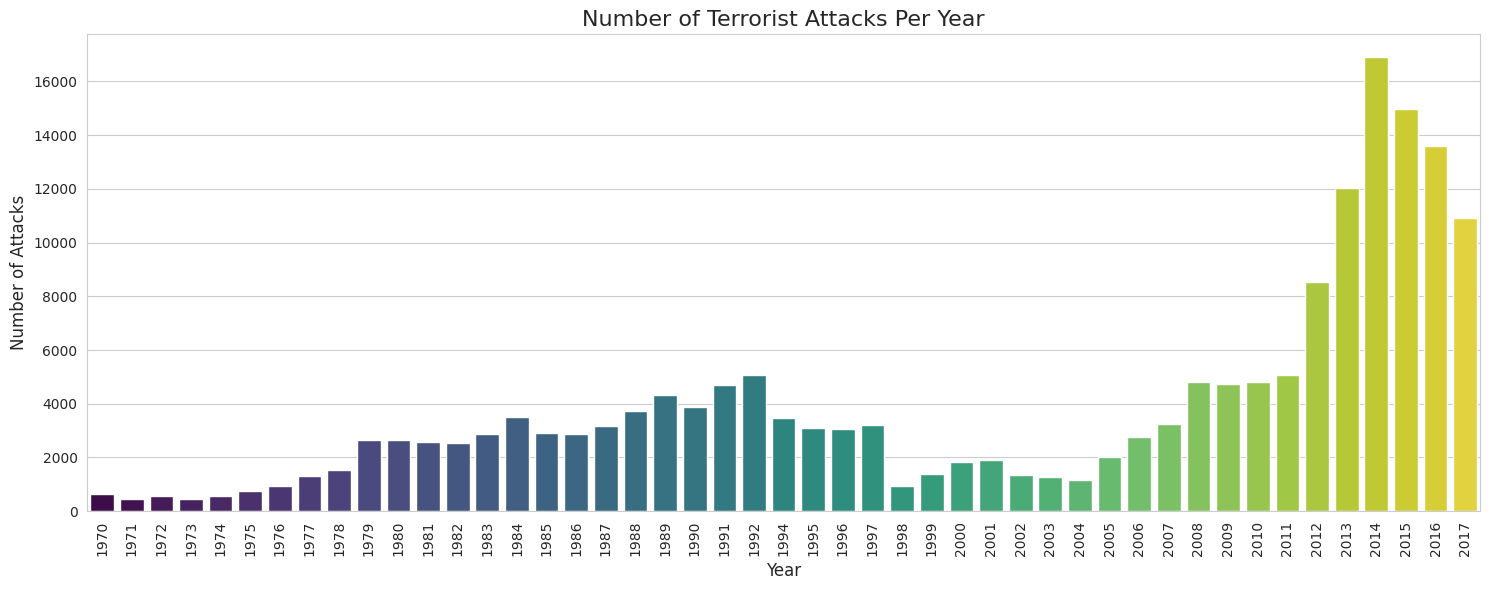

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

plt.figure(figsize=(15, 6))
sns.countplot(x='iyear', data=df, palette='viridis', hue='iyear', legend=False)
plt.title('Number of Terrorist Attacks Per Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Attacks', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Visualization 2: Top 10 most affected countries

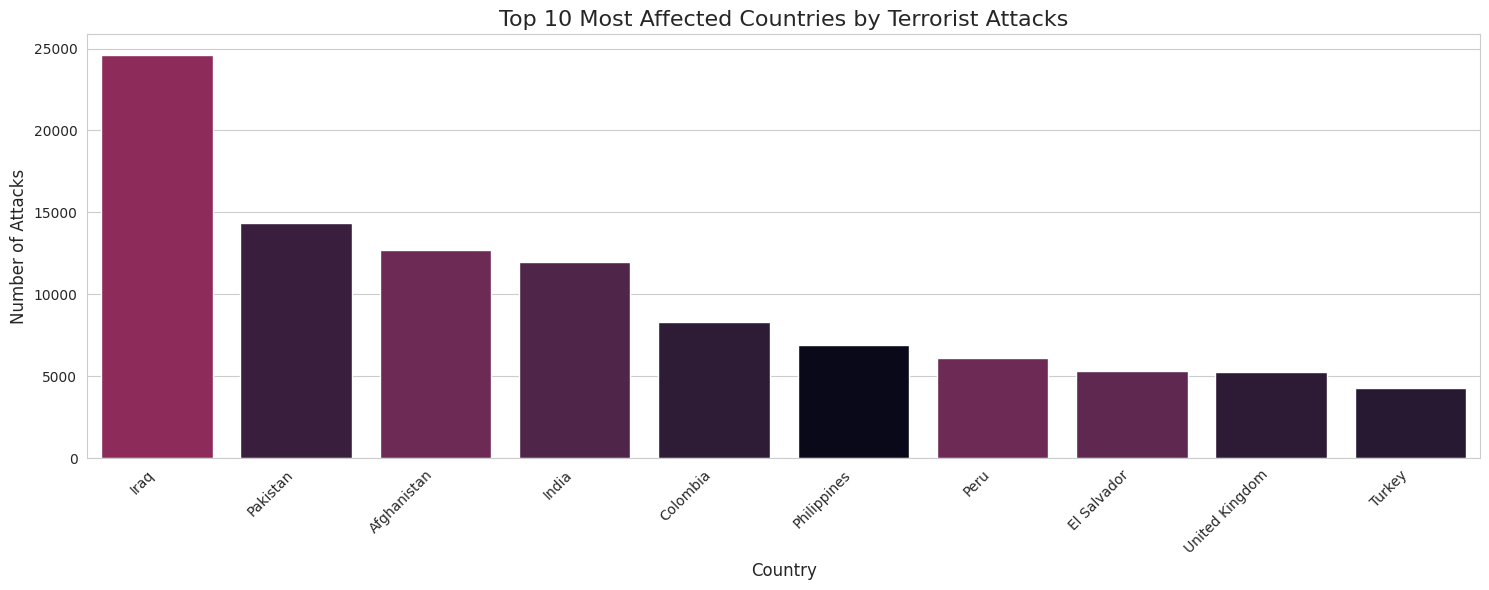

In [ ]:

plt.figure(figsize=(15, 6))
sns.countplot(x='country_txt', data=df, order=df['country_txt'].value_counts().index[:10], palette='rocket', hue='country_txt', legend=False)
plt.title('Top 10 Most Affected Countries by Terrorist Attacks', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Attacks', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualization 3: Top 10 most affected regions

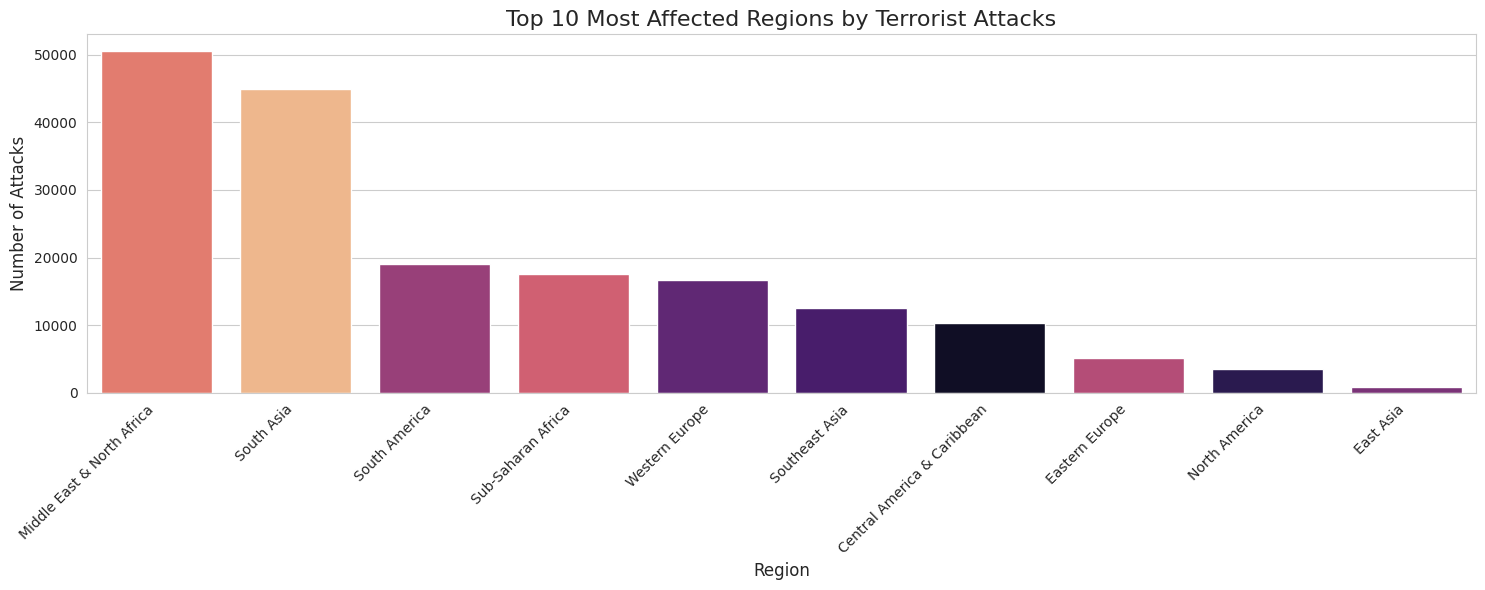

In [ ]:

plt.figure(figsize=(15, 6))
sns.countplot(x='region_txt', data=df, order=df['region_txt'].value_counts().index[:10], palette='magma', hue='region_txt', legend=False)
plt.title('Top 10 Most Affected Regions by Terrorist Attacks', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Attacks', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualization 4: Top 10 most common attack types

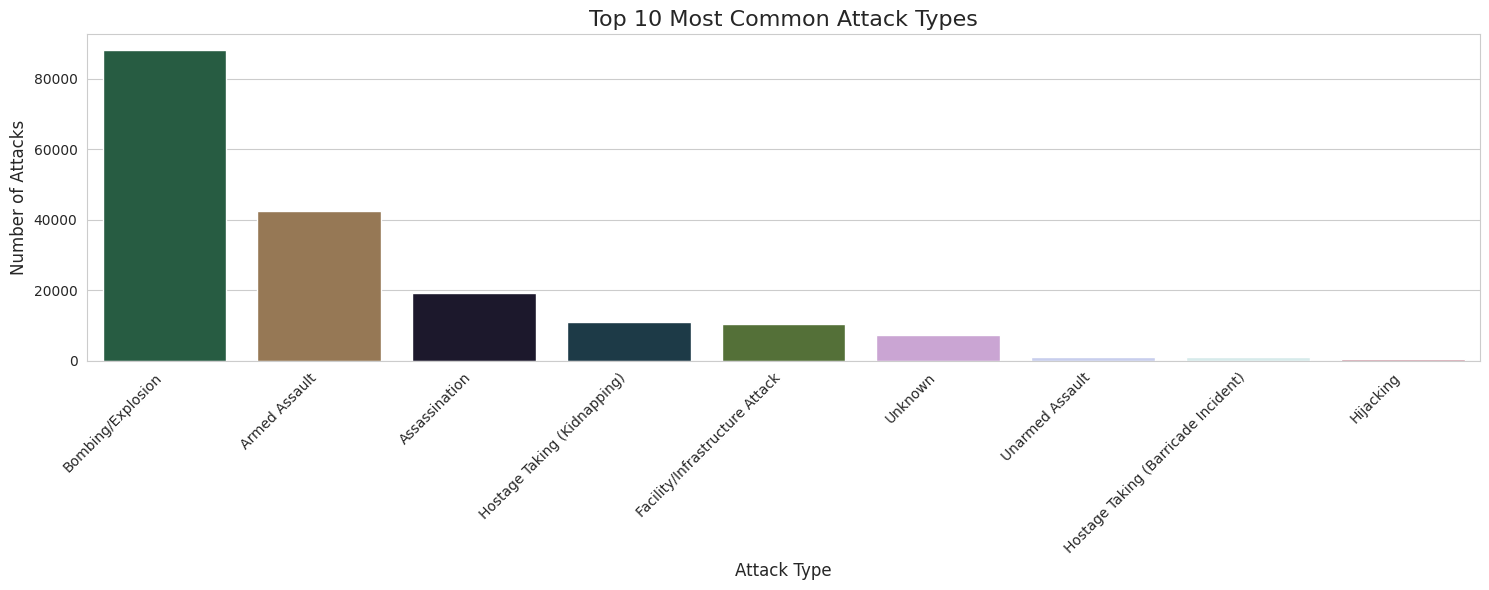

In [ ]:

plt.figure(figsize=(15, 6))
sns.countplot(x='attacktype1_txt', data=df, order=df['attacktype1_txt'].value_counts().index[:10], palette='cubehelix', hue='attacktype1_txt', legend=False)
plt.title('Top 10 Most Common Attack Types', fontsize=16)
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Number of Attacks', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualization 5: Top 10 most common targets

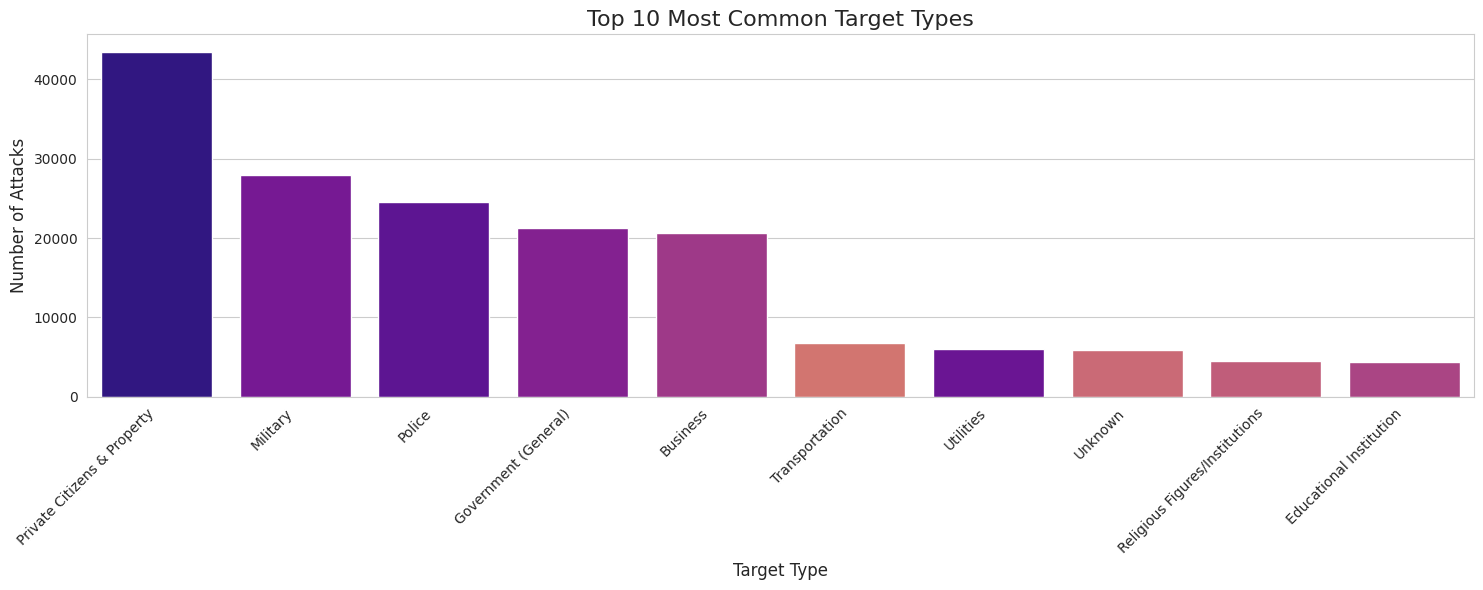

In [ ]:

plt.figure(figsize=(15, 6))
sns.countplot(x='targtype1_txt', data=df, order=df['targtype1_txt'].value_counts().index[:10], palette='plasma', hue='targtype1_txt', legend=False)
plt.title('Top 10 Most Common Target Types', fontsize=16)
plt.xlabel('Target Type', fontsize=12)
plt.ylabel('Number of Attacks', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# VISUALISATION 6: Top 10 weapon types used

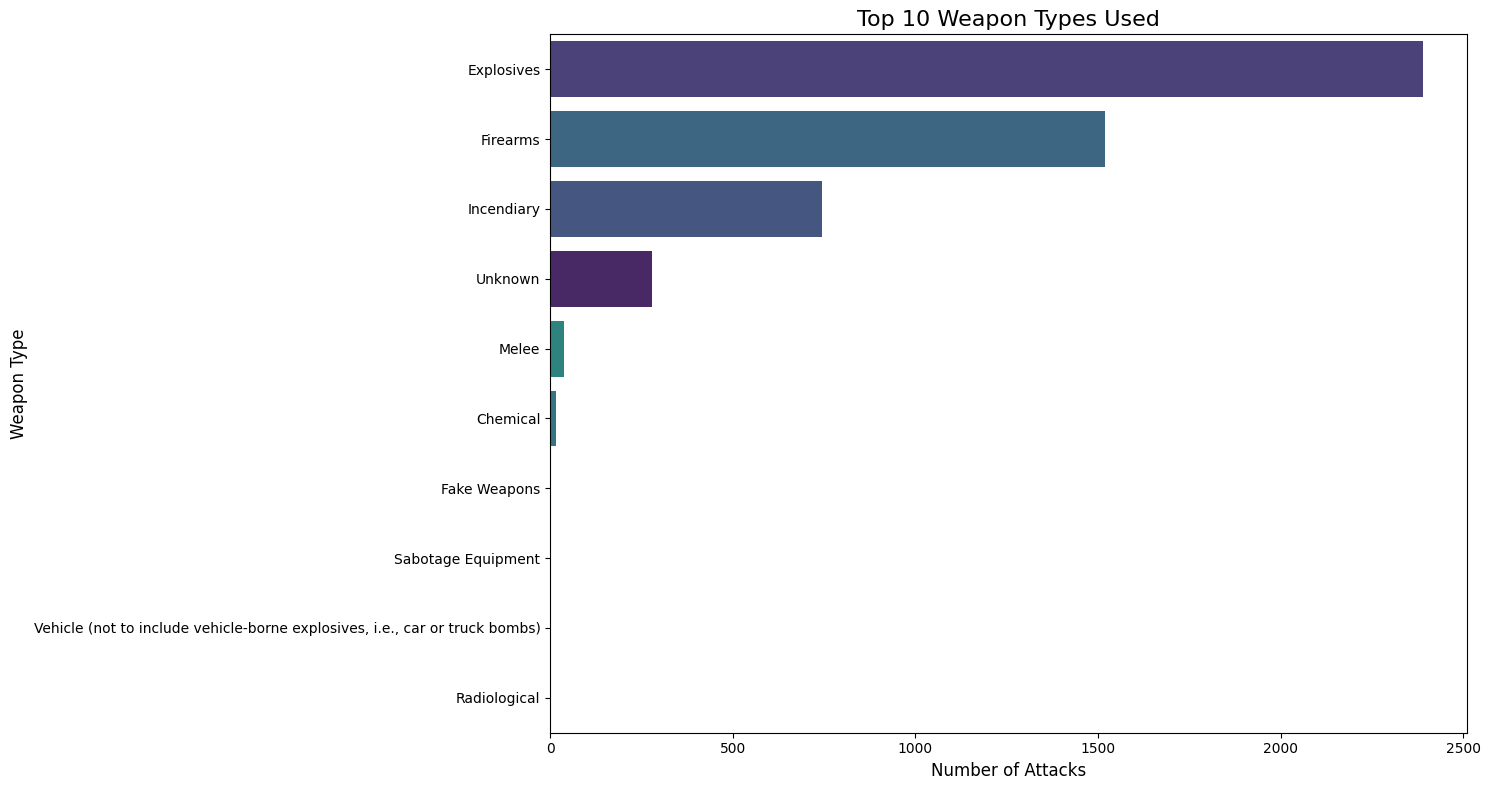

In [ ]:
plt.figure(figsize=(15, 8)) # Increased figure height for better readability
sns.countplot(y='weaptype1_txt', data=df, order=df['weaptype1_txt'].value_counts().index[:10], palette='viridis', hue='weaptype1_txt', legend=False)
plt.title('Top 10 Weapon Types Used', fontsize=16)
plt.xlabel('Number of Attacks', fontsize=12) # Swapped labels
plt.ylabel('Weapon Type', fontsize=12) # Swapped labels
# Removed xticks rotation as it's now horizontal
plt.tight_layout()
plt.show()

#VISUALISATION – 6: Monthly Pattern of Attacks

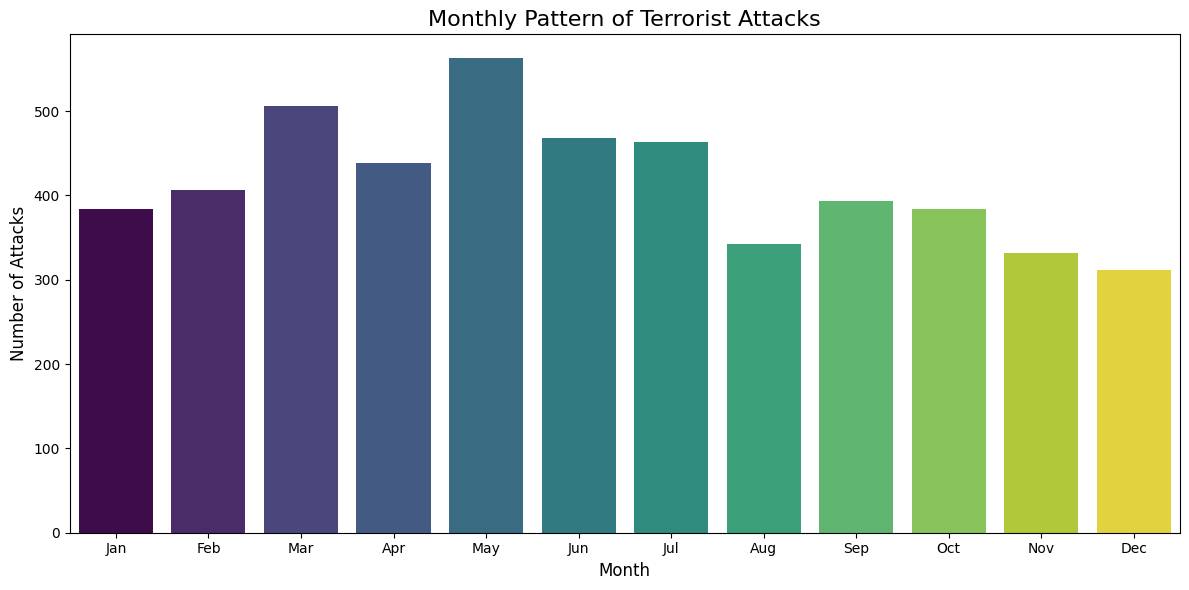

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='imonth', data=df, palette='viridis', hue='imonth', legend=False)
plt.title('Monthly Pattern of Terrorist Attacks', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Attacks', fontsize=12)
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()

## Casualty Analysis: Understanding the Impact of Attacks

To understand the impact of terrorist attacks, we will analyze the distribution of casualties, focusing on the number of people killed (`nkill`) and wounded (`nwound`).

In [ ]:
print("Descriptive statistics for 'nkill':")
display(df['nkill'].describe())

print("\nDescriptive statistics for 'nwound':")
display(df['nwound'].describe())

Descriptive statistics for 'nkill':


,nkill
count,181691.000000
mean,2.266860
std,11.227057
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,1570.000000



Descriptive statistics for 'nwound':


,nwound
count,181691.000000
mean,2.883296
std,34.309747
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,8191.000000


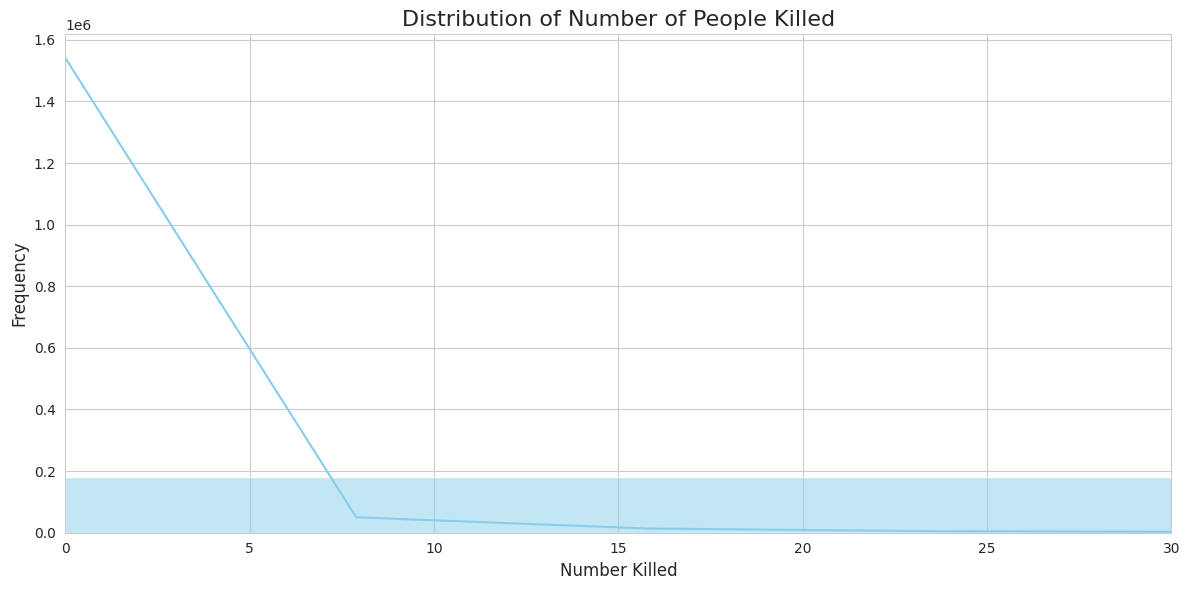

In [ ]:
# Visualization 7: Distribution of people killed (nkill)
plt.figure(figsize=(12, 6))
sns.histplot(df['nkill'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Number of People Killed', fontsize=16)
plt.xlabel('Number Killed', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, df['nkill'].quantile(0.99)) # Limit x-axis to focus on the majority of data
plt.tight_layout()
plt.show()

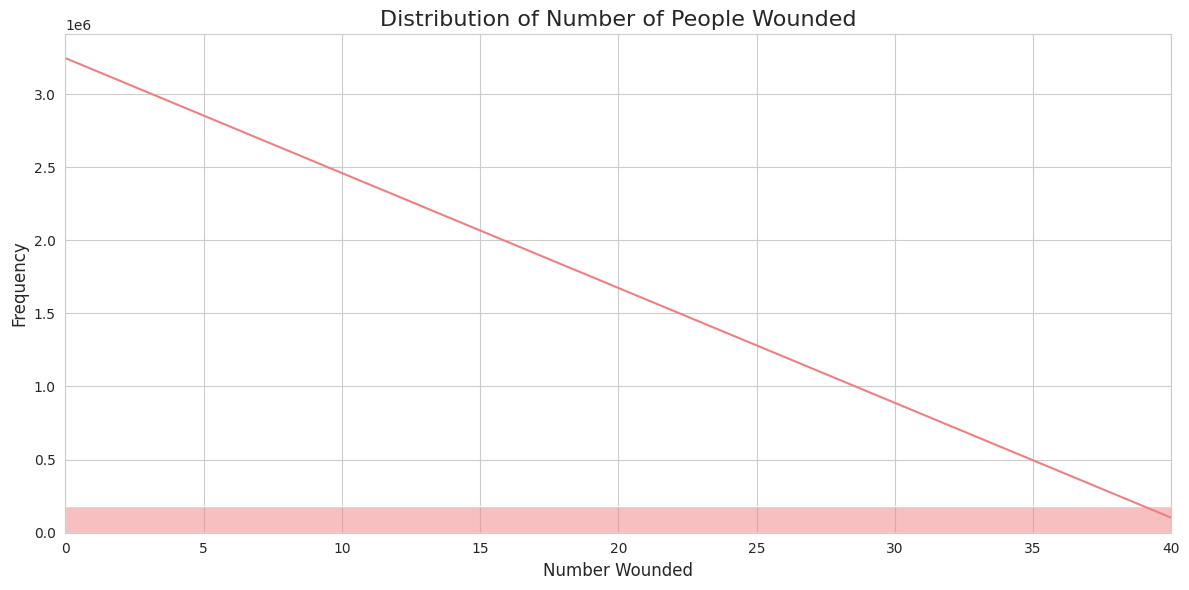

In [ ]:
# Visualization 8: Distribution of people wounded (nwound)
plt.figure(figsize=(12, 6))
sns.histplot(df['nwound'], bins=50, kde=True, color='lightcoral')
plt.title('Distribution of Number of People Wounded', fontsize=16)
plt.xlabel('Number Wounded', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, df['nwound'].quantile(0.99)) # Limit x-axis to focus on the majority of data
plt.tight_layout()
plt.show()

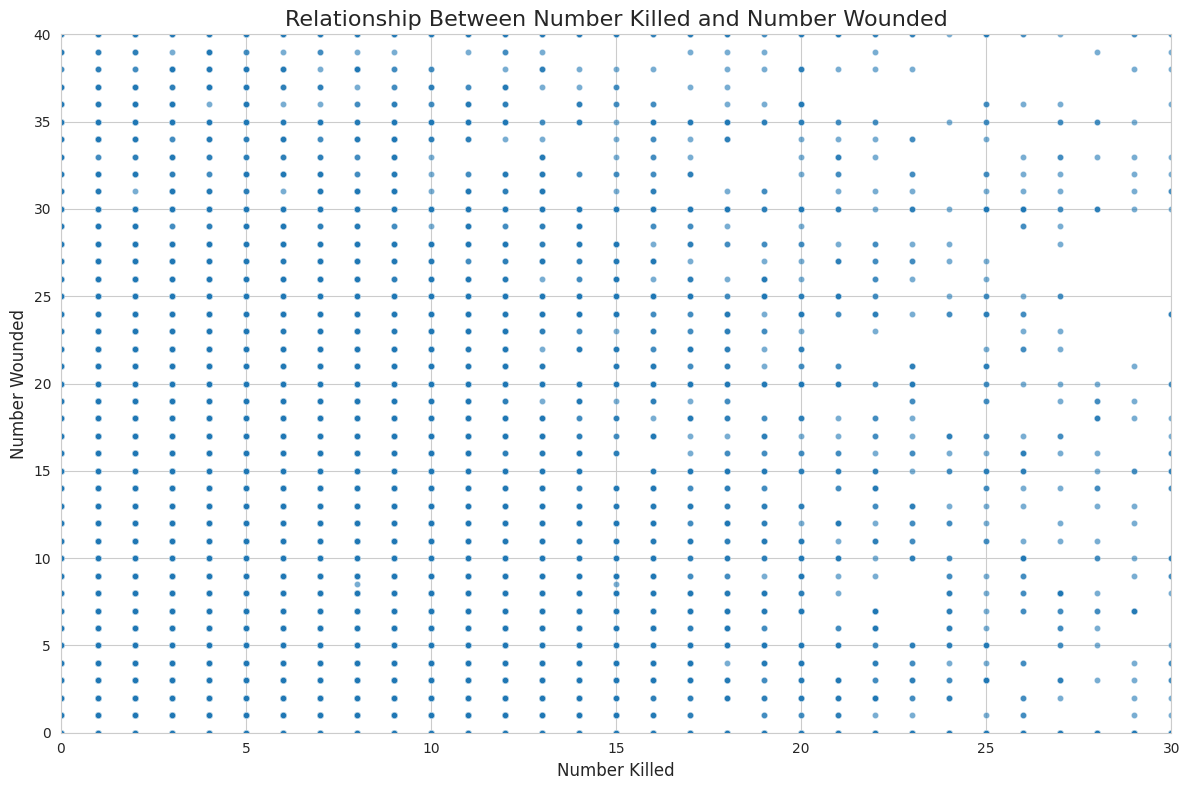

In [ ]:
# Visualization 9: Relationship between killed and wounded
# Create a new column for total casualties for better understanding
df['total_casualties'] = df['nkill'] + df['nwound']

plt.figure(figsize=(12, 8))
sns.scatterplot(x='nkill', y='nwound', data=df, alpha=0.6, s=20)
plt.title('Relationship Between Number Killed and Number Wounded', fontsize=16)
plt.xlabel('Number Killed', fontsize=12)
plt.ylabel('Number Wounded', fontsize=12)
# Limit axes to focus on the most common range, excluding extreme outliers for better visualization
plt.xlim(0, df['nkill'].quantile(0.99))
plt.ylim(0, df['nwound'].quantile(0.99))
plt.tight_layout()
plt.show()

Chart – 9: Attack Type vs. Average Casualties (Grouped)

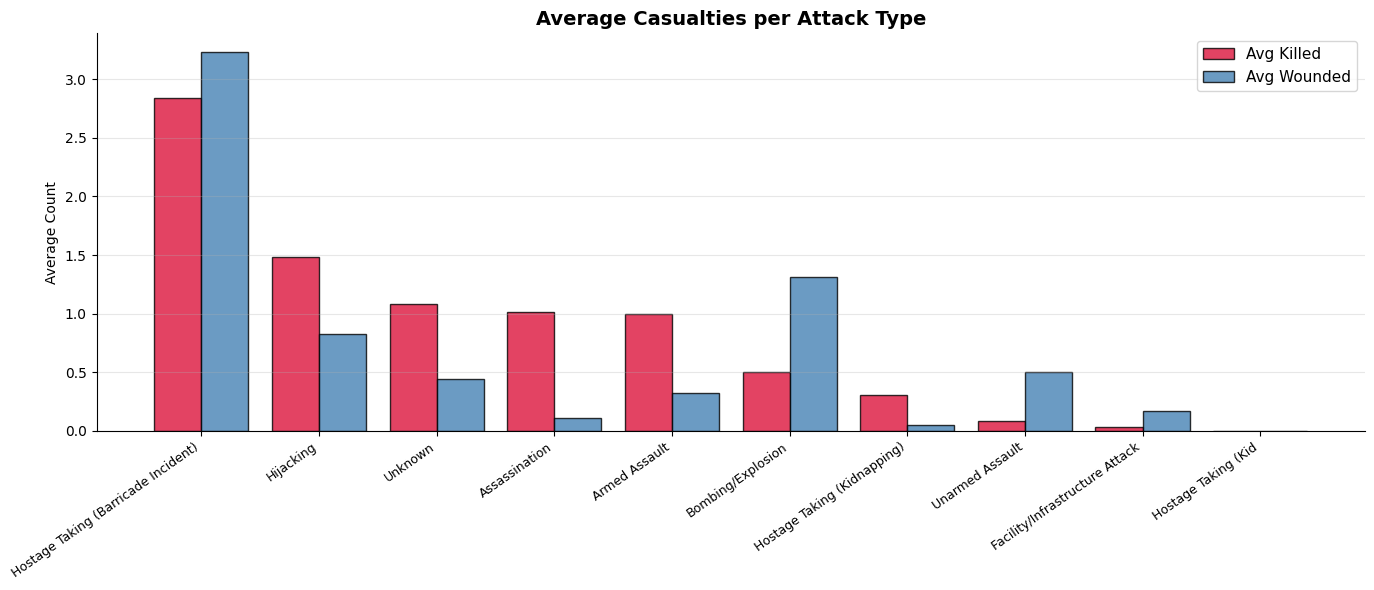

In [ ]:
# ── Why: Grouped bar — compare attack type × casualty metric ────────────
atk_cas = df.groupby('attacktype1_txt').agg(
    avg_killed=('nkill', 'mean'),
    avg_wounded=('nwound', 'mean')
).round(2).sort_values('avg_killed', ascending=False).reset_index()

x = np.arange(len(atk_cas))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, atk_cas['avg_killed'], width, label='Avg Killed',
               color='crimson', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, atk_cas['avg_wounded'], width, label='Avg Wounded',
               color='steelblue', edgecolor='black', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(atk_cas['attacktype1_txt'], rotation=35, ha='right', fontsize=9)
ax.set_title('Average Casualties per Attack Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Count')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

Chart – 10: Top 15 Terrorist Groups by Attacks

/tmp/ipykernel_14695/1909132564.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=top_groups.values, y=top_groups.index,


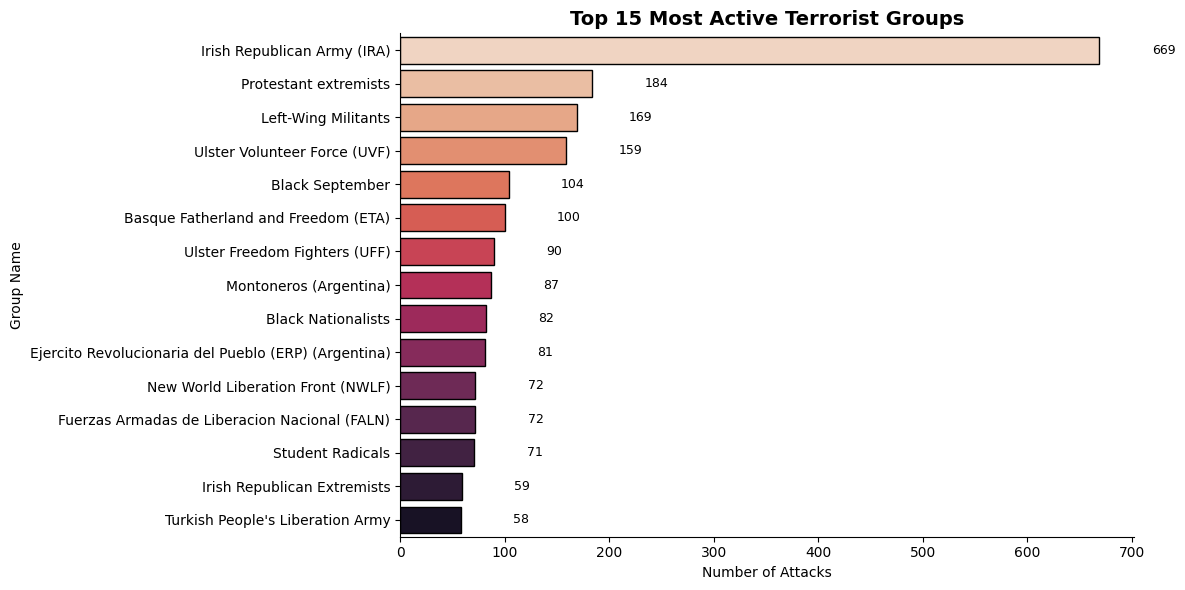

In [ ]:
# ── Why: Horizontal bar — ranked comparison of many categories ──────────
top_groups = (df[df['gname'] != 'Unknown']['gname']
              .value_counts().head(15))

plt.figure(figsize=(12, 6))
bars = sns.barplot(x=top_groups.values, y=top_groups.index,
                   palette='rocket_r', edgecolor='black')
for bar, val in zip(bars.patches, top_groups.values):
    bars.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
              f'{val:,}', va='center', fontsize=9)
plt.title('Top 15 Most Active Terrorist Groups', fontsize=14, fontweight='bold')
plt.xlabel('Number of Attacks')
plt.ylabel('Group Name')
sns.despine()
plt.tight_layout()
plt.show()

5. Feature Engineering & Data Pre-processing

In [ ]:
# ── Verify final working dataframe ───────────────────────────────────────
print("Final cleaned dataframe:")
column_info_all(df)

Final cleaned dataframe:
<class 'pandas.core.frame.DataFrame'>
Index: 4994 entries, 0 to 5095
Data columns (total 136 columns):
 #    Column              Non-Null Count  Dtype  
---   ------              --------------  -----  
 0    eventid             4994 non-null   int64  
 1    iyear               4994 non-null   int64  
 2    imonth              4994 non-null   int64  
 3    iday                4994 non-null   int64  
 4    approxdate          16 non-null     object 
 5    extended            4994 non-null   int64  
 6    resolution          142 non-null    object 
 7    country             4994 non-null   int64  
 8    country_txt         4994 non-null   object 
 9    region              4994 non-null   int64  
 10   region_txt          4994 non-null   object 
 11   provstate           4994 non-null   object 
 12   city                4994 non-null   object 
 13   latitude            4994 non-null   float64
 14   longitude           4994 non-null   float64
 15   specificity     

In [ ]:
df['lethality_index'] = np.where(
    df['total_casualties'] > 0,
    df['nkill'] / df['total_casualties'],
    0
)

print("Lethality Index Stats:")
print(df['lethality_index'].describe().round(3))

Lethality Index Stats:
count    4994.000
mean        0.321
std         0.462
min         0.000
25%         0.000
50%         0.000
75%         1.000
max         1.000
Name: lethality_index, dtype: float64


In [ ]:
# ── Feature: High-Impact Attack flag ─────────────────────────────────────
# Attacks with total casualties > 75th percentile are "High Impact"
threshold = df['total_casualties'].quantile(0.75)
df['high_impact'] = (df['total_casualties'] > threshold).astype(int)

print(f"75th percentile casualty threshold : {threshold:.1f}")
print(f"High-impact attacks                 : {df['high_impact'].sum():,} "
      f"({df['high_impact'].mean()*100:.1f}%)")

75th percentile casualty threshold : 1.0
High-impact attacks                 : 551 (11.0%)


# Machine Learning Techniques Used

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. K-Nearest Neighbors (KNN)
5. Support Vector Machine (SVM)

# Step 1: Import Libraries
These libraries are required for:

. Data manipulation
. Visualization
. Machine Learning
. Model evaluation

*   List item
*   List item



## ***7. Conclusion***

### Conclusion of EDA

- The UNGTA dataset contains **180,000+ terrorist incidents** spanning 1970–2017, covering **200+ countries**.
- Terrorism has **increased dramatically** since 2001, peaking in **2014** driven by ISIS/ISIL's rise.
- **Bombing/Explosion** is the dominant attack type (~50% of all incidents); **Explosives** and **Firearms** are the primary weapons.
- **Middle East & North Africa** and **South Asia** bear the heaviest burden of attacks.
- **Iraq** is the most attacked country; **Baghdad** is the most attacked city.
- **Taliban** and **ISIS/ISIL** are the most active groups; Al-Qaida executes fewer attacks but with far higher per-attack lethality.
- **Suicide attacks**, while a minority, cause significantly more deaths on average (confirmed by Welch's t-test, p ≪ 0.05).
- Region and Attack Type are **significantly associated** (Chi-square, p ≪ 0.05) — regional specialisation of attack methods exists.
- Target Type significantly affects attack success rate — **hardened targets** (military, government) have lower success rates.

